<a href="https://colab.research.google.com/github/yooongZa/AIFFEL_Quest_EPA/blob/main/NLP/NLP03/0907_News_Bot_Projct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 뉴스 요약봇 만들기 [프로젝트]

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 1. 뉴스기사 요약해보기

> 💡 **GPU 런타임 사용을 권장합니다.**

새로운 데이터셋에 대해서 추상적 요약과 추출적 요약을 모두 해보는 시간을 가져봐요.

먼저 주요 라이브러리 버전을 확인해 보죠.

### 답안 구현 기준

- `Based-On: NLP-01-02-C012@40a30afc8988` — 공백 tokenization(토큰화), word↔ID, padding(패딩)
- 참고 예제: `NLP-01-01-C008@2fe05534e124`, `NLP-01-02-C011@a69ad5a21a6c`, `MLDL-03-02-C057@46154b169e1c`, `MLDL-03-02-C061@1eeb3dd65f47`
- 직접 레슨: `뉴스 요약봇 만들기.ipynb` (`lms_export_with_user_state`)

레슨의 **전처리 → 분할 → 단어장 → 패딩 → Encoder/Decoder/Attention → 학습 → 추론 → Summa** 순서를 그대로 따릅니다.

In [1]:
from google.colab import drive
from pathlib import Path
import os

# 기본 마운트 위치에 다른 파일이 있으면 별도 폴더를 사용합니다.
drive_root = Path("/content/drive")
if not os.path.ismount(drive_root):
    if drive_root.exists() and any(drive_root.iterdir()):
        drive_root = Path("/content/google_drive")
    drive.mount(str(drive_root))

data_dir = drive_root / "MyDrive/Aiffel_EPA/news_summarization/data"
data_dir.mkdir(parents=True, exist_ok=True)
print("Google Drive 경로:", data_dir)

Mounted at /content/drive
Google Drive 경로: /content/drive/MyDrive/Aiffel_EPA/news_summarization/data


In [2]:
!pip install -q summa nltk

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.9/54.9 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [3]:
import html
import random
import re
from collections import Counter
from copy import deepcopy

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from nltk.corpus import stopwords
from torch.utils.data import DataLoader, TensorDataset

nltk.download("stopwords", quiet=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

## Step 1. 데이터 수집하기

데이터는 아래 링크에 있는 뉴스 기사 데이터(`news_summary_more.csv`)를 사용하세요.
- [sunnysai12345/News_Summary](https://github.com/sunnysai12345/News_Summary)<br>

아래의 코드로 데이터를 다운로드할 수 있어요.

In [4]:
from urllib.request import urlretrieve

data_url = (
    "https://raw.githubusercontent.com/sunnysai12345/News_Summary/"
    "a86081060bbb17c5686b478b2f7f18df6e87303d/news_summary_more.csv"
)
data_path = data_dir / "news_summary_more.csv"

# Drive에 파일이 없을 때만 다운로드합니다.
if not data_path.exists():
    urlretrieve(data_url, data_path)

data = pd.read_csv(data_path, encoding="iso-8859-1")
print("전체 샘플 수:", len(data))

전체 샘플 수: 98401


In [5]:
data.sample(10, random_state=SEED)

,headlines,text
32571,K'taka students to get extra marks if parents ...,Students in Karnataka will get extra marks if ...
35184,Syria shoots down missiles fired at two air bases,Syrian anti-aircraft defences on Monday shot d...
59997,Dinosaur-like animal's fossil found in Uttarak...,A Dinosaur-like creature's fossil was found du...
64665,"UP may merge Shia, Sunni Waqf boards to preven...",The Uttar Pradesh government is planning to fo...
15343,Egypt actress gets 2 yrs jail for 'fake news' ...,Egyptian activist-actress Amal Fathy has been ...
52898,Jeff Bezos added more wealth in 2017 than GDP ...,World's richest person and Amazon CEO Jeff Bez...
95149,Bangladeshi captain Mortaza announces retireme...,Bangladesh cricket team's limited overs captai...
76915,Mexican drug lord El Chapo questions US extrad...,Mexican drug lord Joaquin 'El Chapo' Guzman ha...
49398,N Korea supplies ballistic missiles to Myanmar...,Independent United Nations (UN) monitors have ...
74036,Thenga mila hamme: Harbhajan responds to home ...,After reports of three Amrapali Group companie...


## Step 2. 데이터 전처리하기 (추상적 요약)


`Text`에서는 stopword(불용어)를 제거하고, 짧은 정답인 `Summary`에서는 제거하지 않습니다.

In [6]:
data = data[["text", "headlines"]].rename(
    columns={"text": "Text", "headlines": "Summary"}
)
data = data.drop_duplicates(subset=["Text"]).dropna().copy()

# Summa 비교에는 전처리 전 원문을 사용합니다.
data["OriginalText"] = data["Text"]
print("중복과 결측치 제거 후:", len(data))

중복과 결측치 제거 후: 98360


In [7]:
#contractions 딕셔너리: 이 딕셔너리는 'ain't', 'can't'와 같은 영어 축약어를 'is not', 'cannot'과 같이 원래 형태로 확장하기 위한 매핑을 포함하고 있습니다. 텍스트 정규화에 사용됩니다.
contractions = {
    "ain't": "is not", "aren't": "are not", "can't": "cannot",
    "couldn't": "could not", "didn't": "did not", "doesn't": "does not",
    "don't": "do not", "hadn't": "had not", "hasn't": "has not",
    "haven't": "have not", "he's": "he is", "i'm": "i am",
    "isn't": "is not", "it's": "it is", "let's": "let us",
    "shouldn't": "should not", "that's": "that is", "there's": "there is",
    "they're": "they are", "wasn't": "was not", "we're": "we are",
    "weren't": "were not", "what's": "what is", "where's": "where is",
    "who's": "who is", "won't": "will not", "wouldn't": "would not",
    "you're": "you are", "you've": "you have"
}
stop_words = set(stopwords.words("english"))
#stop_words 집합: nltk.corpus.stopwords에서 영어 불용어(예: 'a', 'the', 'is' 등)를 가져와 집합(set) 형태로 저장합니다. 이 단어들은 문장의 의미에 크게 기여하지 않으므로, 텍스트 분석 전에 제거하는 경우가 많습니다.

def preprocess_sentence(sentence, remove_stopwords=True):
    sentence = sentence.lower()
    sentence = re.sub("<[^>]*>", " ", sentence)       # HTML 태그 제거
    sentence = html.unescape(sentence)                  # &amp; 같은 문자 변환
    sentence = re.sub(r"\([^)]*\)", " ", sentence)    # 괄호 내용 제거
    sentence = " ".join(
        contractions.get(word, word) for word in sentence.split()
    )
    sentence = re.sub(r"'s\b", "", sentence)
    sentence = re.sub("[^a-zA-Z]", " ", sentence)

    words = sentence.split()
    if remove_stopwords:
        words = [word for word in words if word not in stop_words]
    return " ".join(word for word in words if len(word) > 1)

# preprocess_sentence(sentence, remove_stopwords=True) 함수: 이 함수는 주어진 문장을 받아 여러 전처리 단계를 수행합니다.
  # sentence.lower(): 모든 문자를 소문자로 변환하여 대소문자 차이로 인한 동일 단어의 다른 취급을 방지합니다.
  # re.sub("<[^"]*">, " ", sentence): <p>, <a>와 같은 HTML 태그를 공백으로 대체하여 제거합니다.
  # html.unescape(sentence): &amp;, &lt;와 같은 HTML 엔티티를 '&', '<'와 같은 실제 문자로 변환합니다.
  # re.sub(r"\([^)]*\)", " ", sentence): 괄호 () 안에 있는 모든 내용을 공백으로 대체하여 제거합니다.
  # " ".join(contractions.get(word, word) for word in sentence.split()): 문장을 단어 단위로 분리한 후, 위에서 정의된 contractions 딕셔너리를 사용하여 축약어를 확장합니다.
  # re.sub(r"'s\b", "", sentence): 소유격을 나타내는 "'s"를 제거합니다. (예: "he's"는 이미 축약어 처리에서 확장되었으므로, 주로 "word's" 형태를 처리합니다.)
  # re.sub("[^a-zA-Z]", " ", sentence): 알파벳 문자(a-z, A-Z)를 제외한 모든 문자를 공백으로 대체하여 구두점이나 숫자 등을 제거합니다.
  # words = sentence.split(): 처리된 문장을 다시 단어 리스트로 분리합니다.
  # if remove_stopwords: 블록: remove_stopwords 인수가 True인 경우, stop_words 집합에 있는 단어들을 제거합니다.
  # 마지막으로, len(word) > 1 조건을 만족하는 (즉, 길이가 1보다 큰) 단어들만 다시 공백으로 연결하여 반환합니다. 이는 단일 문자(예: 'a', 'i')나 전처리 과정에서 생긴 잔여물을 제거하는 데 도움이 됩니다.


In [8]:
data["Text"] = data["Text"].apply(preprocess_sentence)
data["Summary"] = data["Summary"].apply(
    lambda sentence: preprocess_sentence(sentence, remove_stopwords=False)
)

# 전처리 후 빈 문자열은 제거합니다.
data = data.replace("", np.nan).dropna().reset_index(drop=True)
data[["Text", "Summary"]].head()

data["Text"] = data["Text"].apply(preprocess_sentence)

# 기사 본문인 Text 열의 모든 문장에 전처리 함수를 적용합니다.
# 함수의 기본값이 remove_stopwords=True이므로 텍스트 정제와 함께 불용어(의미가 없는 단어) 제거도 함께 수행됩니다.
# data["Summary"] = data["Summary"].apply(lambda sentence: preprocess_sentence(sentence, remove_stopwords=False))

# 요약문인 Summary 열에 전처리 함수를 적용합니다.
# 요약문은 본문보다 훨씬 짧고 핵심만 담고 있어서 불용어를 제거하면 문맥이 어색해지거나 의미가 훼손될 수 있습니다.
# 따라서 일회성 함수인 lambda 함수를 써서 remove_stopwords=False 옵션을 명시하여 불용어는 남겨두고 나머지 정제 작업만 수행합니다.
# 여기서 lambda sentence: 는 "입력값으로 sentence를 받아서", : preprocess_sentence(sentence, remove_stopwords=False) 는 **"불용어 제거 옵션을 끈 상태로 전처리 함수를 실행해라"**라는 뜻입니다.
# data = data.replace("", np.nan).dropna().reset_index(drop=True)

# 전처리를 거치면서 특수문자나 불용어만 있던 문장은 빈 문자열("")이 될 수 있습니다.
# 이런 빈 문자열을 넘파이의 결측치(np.nan)로 바꾼 후, dropna()를 이용해 해당 행을 데이터셋에서 완전히 삭제합니다.
# 삭제 후 중간에 비어버린 인덱스를 reset_index(drop=True)로 깔끔하게 0부터 다시 정렬해 줍니다.
# data[["Text", "Summary"]].head()

# 전처리가 완료된 데이터의 첫 5행을 출력하여 결과를 확인합니다.

/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47928 (\N{HANGUL SYLLABLE MUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51109 (\N{HANGUL SYLLABLE JANG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44600 (\N{HANGUL SYLLABLE GIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49368 (\N{HANGUL SYLLABLE SAEM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

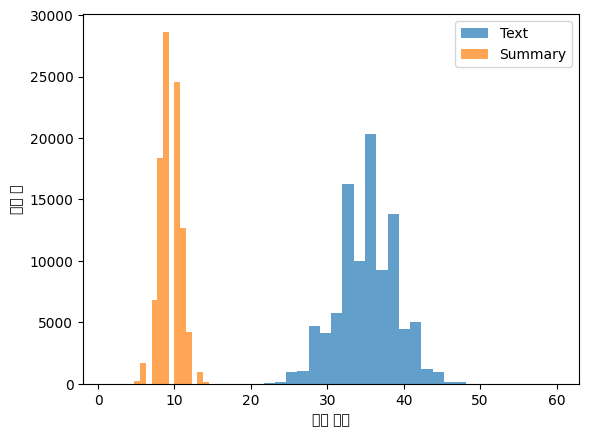

훈련 데이터: 77752
테스트 데이터: 19438


In [9]:
text_lengths = data["Text"].str.split().str.len()
summary_lengths = data["Summary"].str.split().str.len()

plt.hist(text_lengths, bins=40, alpha=0.7, label="Text")
plt.hist(summary_lengths, bins=20, alpha=0.7, label="Summary")
plt.xlabel("문장 길이")
plt.ylabel("샘플 수")
plt.legend()
plt.show()

text_max_len = 50
summary_max_len = 12
data = data[
    (text_lengths <= text_max_len) &
    (summary_lengths <= summary_max_len)
].copy()

# 디코더 입력에는 시작 토큰, 정답에는 종료 토큰을 붙입니다.
data["decoder_input"] = "sostoken " + data["Summary"]
data["decoder_target"] = data["Summary"] + " eostoken"

# 데이터를 섞은 뒤 8:2로 나눕니다.
data = data.sample(frac=1, random_state=SEED).reset_index(drop=True)
split_index = int(len(data) * 0.8)
train_data = data.iloc[:split_index].reset_index(drop=True)
test_data = data.iloc[split_index:].reset_index(drop=True)

print("훈련 데이터:", len(train_data))
print("테스트 데이터:", len(test_data))


# 길이 분포 확인 및 시각화: Text와 Summary 열의 문장을 단어 단위로 쪼개어 길이를 구하고,
# 히스토그램으로 그려서 데이터의 전반적인 길이 분포를 확인합니다.
# 최대 길이에 따른 필터링: 시각화 결과를 바탕으로 본문(Text)은 50단어 이하, 요약문(Summary)은 8단어 이하인 샘플만 남깁니다.
# 모델의 학습 효율을 높이고 이상치를 제거하기 위함입니다.
# 디코더 특수 토큰 추가: Seq2Seq 모델의 디코더가 문장의 시작과 끝을 인식할 수 있도록,
# 요약문 앞에 시작 토큰(sostoken)을 붙인 decoder_input 열과 끝에 종료 토큰(eostoken)을 붙인 decoder_target 열을 생성합니다.
# 데이터 분할: 데이터를 무작위로 섞은 후, 전체 데이터를 8:2 비율로 나누어 훈련용(train_data)과 테스트용(test_data)으로 분리합니다.

In [10]:
# build_vocab: 텍스트에서 단어의 등장 빈도를 세어 가장 자주 나오는 단어들로 **단어장(Vocabulary)**을 만듭니다.
# 인덱스 0은 빈 칸을 채울 <PAD>, 1은 단어장에 없는 단어를 처리할 <UNK>(Unknown)로 지정합니다.
def build_vocab(texts, max_size):
    counter = Counter()
    for text in texts:
        counter.update(text.split())

    vocab = {"<PAD>": 0, "<UNK>": 1}
    for word, _ in counter.most_common(max_size - 2):
        vocab[word] = len(vocab)
    return vocab

# text_to_sequences: 입력된 문장의 각 단어를 단어장을 참조해 숫자로 변환합니다.
def text_to_sequences(texts, vocab):
    sequences = []
    for text in texts:
        sequence = [vocab.get(word, vocab["<UNK>"]) for word in text.split()]
        sequences.append(sequence)
    return sequences


# pad_sequences: 모델은 입력 크기가 일정해야 하므로, 문장의 길이를 max_len으로 고정합니다.
# 짧으면 남는 공간을 0으로 채우고(패딩), 길면 잘라냅니다.
def pad_sequences(sequences, max_len):
    result = torch.zeros((len(sequences), max_len), dtype=torch.long)
    for row, sequence in enumerate(sequences):
        length = min(len(sequence), max_len)
        result[row, :length] = torch.tensor(sequence[:length])
    return result


# 단어장 생성:
# 인코더(원문 텍스트)용 단어장 src_vocab은 최대 8,000개 단어로 제한하여 생성합니다.
# 디코더(요약문)용 단어장 tar_vocab은 최대 2,000개 단어로 제한하여 생성합니다.(4000으로 변경 재실험)
# 이때 Seq2Seq 모델 구동에 필수적인 시작 토큰(sostoken)과 종료 토큰(eostoken)이 빈도수 제한에 걸려 잘려나가지 않도록
# 수동으로 단어장에 추가해 줍니다.
src_vocab = build_vocab(train_data["Text"], max_size=8000)
target_texts = list(train_data["decoder_input"]) + list(train_data["decoder_target"])
tar_vocab = build_vocab(target_texts, max_size=8000)



# 데이터 변환 (숫자화 및 패딩):
# 앞서 만든 함수들을 사용하여 train_data와 test_data의 텍스트들을 전부 숫자 텐서로 바꿉니다.
# 본문(Text)은 50단어 길이, 요약문(decoder_input/target)은 9단어 길이로 크기를 똑같이 맞춘 뒤
# 파이토치(PyTorch) 모델 학습에 바로 사용할 수 있는 형태로 변환합니다.
# SOS/EOS가 단어장 크기 제한으로 빠지는 경우를 막습니다.
for token in ["sostoken", "eostoken"]:
    if token not in tar_vocab:
        tar_vocab[token] = len(tar_vocab)

decoder_max_len = summary_max_len + 1

encoder_input_train = pad_sequences(
    text_to_sequences(train_data["Text"], src_vocab), text_max_len
)
encoder_input_test = pad_sequences(
    text_to_sequences(test_data["Text"], src_vocab), text_max_len
)
decoder_input_train = pad_sequences(
    text_to_sequences(train_data["decoder_input"], tar_vocab), decoder_max_len
)
decoder_target_train = pad_sequences(
    text_to_sequences(train_data["decoder_target"], tar_vocab), decoder_max_len
)
decoder_input_test = pad_sequences(
    text_to_sequences(test_data["decoder_input"], tar_vocab), decoder_max_len
)
decoder_target_test = pad_sequences(
    text_to_sequences(test_data["decoder_target"], tar_vocab), decoder_max_len
)

print("인코더 입력 shape:", encoder_input_train.shape)
print("디코더 입력 shape:", decoder_input_train.shape)

인코더 입력 shape: torch.Size([77752, 50])
디코더 입력 shape: torch.Size([77752, 13])


## Step 3. 어텐션 메커니즘 사용하기 (추상적 요약)



Encoder는 원문을 읽고, Decoder는 정답 요약을 한 단어씩 예측합니다. Attention은 예측할 때 원문의 어느 부분을 볼지 계산합니다.

In [11]:
# Encoder (인코더): 원문 텍스트를 입력받아 임베딩(Embedding)을 거친 후,
# 3층으로 구성된 LSTM(순환신경망) 모델을 통과시켜 문장의 전반적인 문맥 정보를 압축하여 추출합니다.
class Encoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=3,
            dropout=0.4, batch_first=True
        )

    def forward(self, x):
        x = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(x)
        return outputs, hidden, cell

# Decoder (디코더): 인코더가 압축한 정보를 전달받아,
# 요약문의 단어를 순차적으로 하나씩 예측하며 생성하는 역할을 합니다.
class Decoder(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(
            embedding_dim, hidden_size, num_layers=3,
            dropout=0.4, batch_first=True
        )

    def forward(self, x, hidden, cell):
        x = self.embedding(x)
        outputs, (hidden, cell) = self.lstm(x, (hidden, cell))
        return outputs, hidden, cell

# Attention (어텐션): 디코더가 새로운 단어를 예측할 때마다 원문(인코더 출력)의 어느 부분에 더 '집중(Attention)'해야 할지
# 중요도 점수를 계산합니다. 의미 없는 패딩() 부분은 점수를 낮게 처리(masking)합니다.
class Attention(nn.Module):
    def forward(self, decoder_outputs, encoder_outputs, encoder_input):
        scores = torch.bmm(decoder_outputs, encoder_outputs.transpose(1, 2))
        pad_mask = encoder_input.eq(0).unsqueeze(1)
        scores = scores.masked_fill(pad_mask, -1e9)
        weights = F.softmax(scores, dim=-1)
        return torch.bmm(weights, encoder_outputs)

# Seq2SeqWithAttention: 앞서 만든 인코더, 디코더, 어텐션을 하나로 결합한 최종 모델입니다.
# 디코더의 결과와 어텐션 문맥 벡터를 합쳐(concat) 최종적으로 단어장의 어떤 단어가 다음에 올지 확률을 계산하여 출력합니다.
class Seq2SeqWithAttention(nn.Module):
    def __init__(self, src_vocab_size, tar_vocab_size, embedding_dim, hidden_size):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, embedding_dim, hidden_size)
        self.decoder = Decoder(tar_vocab_size, embedding_dim, hidden_size)
        self.attention = Attention()
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        self.output = nn.Linear(hidden_size, tar_vocab_size)

    def forward(self, encoder_input, decoder_input):
        encoder_outputs, hidden, cell = self.encoder(encoder_input)
        decoder_outputs, _, _ = self.decoder(decoder_input, hidden, cell)
        context = self.attention(decoder_outputs, encoder_outputs, encoder_input)
        combined = torch.cat([decoder_outputs, context], dim=-1)
        combined = torch.tanh(self.concat(combined))
        return self.output(combined)

In [12]:
# 학습 장치 설정: device 변수에 GPU(cuda)가 사용 가능하면 할당하고, 그렇지 않으면 CPU를 사용하도록 설정합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 하이퍼파라미터 정의: 임베딩 차원(128), 은닉층 크기(256), 배치 크기(256), 총 학습 횟수(50), 조기 종료 조건(patience = 2) 등
# 모델 학습에 필요한 주요 설정값들을 정의합니다.
embedding_dim = 128
hidden_size = 256
batch_size = 256
epochs = 50
patience = 2

# 모델 초기화: 앞서 정의한 Seq2SeqWithAttention 클래스를 이용해 모델 객체를 생성하고, 선택된 장치(to(device))로 보냅니다
model = Seq2SeqWithAttention(
    len(src_vocab), len(tar_vocab), embedding_dim, hidden_size
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=0)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.001)
# CrossEntropyLoss: 다중 클래스 분류에 쓰이는 손실 함수입니다.
# ignore_index=0을 통해 패딩(<PAD>) 토큰은 오차 계산에서 제외합니다.
# AdamW: 학습 속도를 조절하며 모델의 가중치를 업데이트하는 최적화 알고리즘입니다.

train_dataset = TensorDataset(
    encoder_input_train, decoder_input_train, decoder_target_train
)
test_dataset = TensorDataset(
    encoder_input_test, decoder_input_test, decoder_target_test
)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size)
# 숫자 텐서로 변환된 인코더/디코더 입력과 정답 데이터를 묶어 TensorDataset으로 만듭니다.
# 이를 지정한 batch_size만큼씩 쪼개어 모델에 공급하기 위해 DataLoader로 감싸줍니다.
# 훈련 데이터는 무작위로 섞어(shuffle=True) 학습 효율을 높입니다.

print("사용 장치:", device)

사용 장치: cuda


In [13]:
#  Seq2Seq 모델을 실제로 학습시키고, 가장 성능이 좋은 상태를 저장하는 훈련 과정(Training Loop)

train_losses = []
val_losses = []
best_val_loss = float("inf")
best_model = None
wait = 0

# 에폭(Epoch) 반복: 설정한 epochs만큼 학습을 반복합니다.
for epoch in range(epochs):
    model.train()
    train_loss = 0

    for encoder_input, decoder_input, target in train_loader:
        encoder_input = encoder_input.to(device)
        decoder_input = decoder_input.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        output = model(encoder_input, decoder_input)
        loss = criterion(output.reshape(-1, output.size(-1)), target.reshape(-1))
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for encoder_input, decoder_input, target in test_loader:
            encoder_input = encoder_input.to(device)
            decoder_input = decoder_input.to(device)
            target = target.to(device)

            output = model(encoder_input, decoder_input)
            loss = criterion(output.reshape(-1, output.size(-1)), target.reshape(-1))
            val_loss += loss.item()

    train_loss /= len(train_loader)
    val_loss /= len(test_loader)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

# 훈련 모드(model.train()):
# train_loader에서 배치 단위로 데이터를 가져옵니다.
# 모델에 인코더/디코더 입력을 넣고 출력(output)을 얻습니다.
# criterion(손실 함수)으로 예측값과 실제 정답(target) 간의 오차(Loss)를 계산합니다.
# loss.backward()로 오차를 역전파하고, optimizer.step()으로 모델의 가중치를 업데이트(학습)합니다.
# 평가 모드(model.eval()):
# 가중치 업데이트를 멈추고(torch.no_grad()), test_loader의 검증 데이터로 모델을 평가하여 val_loss를 계산합니다. 학습이 잘 되고 있는지 확인하는 과정입니다.
# 조기 종료(Early Stopping):
# 매 에폭마다 검증 오차(val_loss)가 역대 최저치(best_val_loss)를 갱신하면 모델 상태를 복사해 둡니다.
# 만약 오차가 줄어들지 않고 patience(여기선 2번)만큼 연속으로 나빠지면, 과적합(Overfitting)을 막기 위해 학습을 조기에 강제 종료합니다.
# 모델 저장: 학습이 끝난 뒤, 가장 성능이 좋았던(검증 오차가 가장 낮았던) 순간의 가중치(best_model)를 불러와 구글 드라이브 경로에 .pt 파일로 안전하게 저장합니다.

    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = deepcopy(model.state_dict())
        wait = 0
    else:
        wait += 1

    if wait >= patience:
        print("Early Stopping")
        break

# 가장 성능이 좋았던 모델을 복원하고 Drive에 저장합니다.
model.load_state_dict(best_model)
model_path = data_dir / "news_seq2seq_attention.pt"
torch.save(model.state_dict(), model_path)
print("모델 저장 완료:", model_path)

# 저장된 모델을 불러오는 방법
model.load_state_dict(torch.load(model_path, map_location=device))

Epoch 1/50 | Train Loss: 6.6586 | Val Loss: 6.3479
Epoch 2/50 | Train Loss: 6.2774 | Val Loss: 6.0805
Epoch 3/50 | Train Loss: 5.9227 | Val Loss: 5.6565
Epoch 4/50 | Train Loss: 5.4626 | Val Loss: 5.2649
Epoch 5/50 | Train Loss: 5.1001 | Val Loss: 4.9894
Epoch 6/50 | Train Loss: 4.8094 | Val Loss: 4.7782
Epoch 7/50 | Train Loss: 4.5776 | Val Loss: 4.6339
Epoch 8/50 | Train Loss: 4.3865 | Val Loss: 4.5254
Epoch 9/50 | Train Loss: 4.2192 | Val Loss: 4.4333
Epoch 10/50 | Train Loss: 4.0750 | Val Loss: 4.3608
Epoch 11/50 | Train Loss: 3.9449 | Val Loss: 4.3077
Epoch 12/50 | Train Loss: 3.8296 | Val Loss: 4.2664
Epoch 13/50 | Train Loss: 3.7216 | Val Loss: 4.2262
Epoch 14/50 | Train Loss: 3.6235 | Val Loss: 4.2113
Epoch 15/50 | Train Loss: 3.5308 | Val Loss: 4.1915
Epoch 16/50 | Train Loss: 3.4469 | Val Loss: 4.1797
Epoch 17/50 | Train Loss: 3.3676 | Val Loss: 4.1743
Epoch 18/50 | Train Loss: 3.2926 | Val Loss: 4.1679
Epoch 19/50 | Train Loss: 3.2221 | Val Loss: 4.1701
Epoch 20/50 | Train L

<All keys matched successfully>

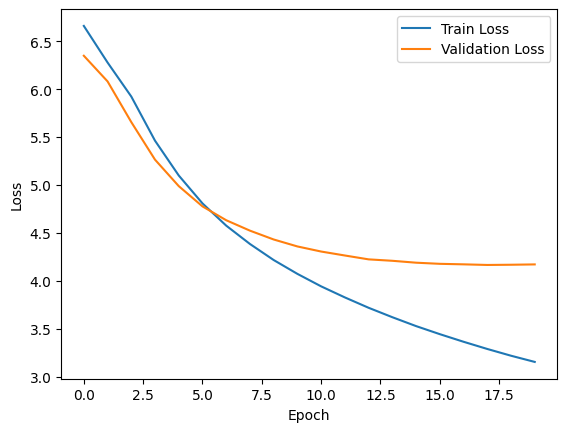

In [14]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

## Step 4. 실제 결과와 요약문 비교하기 (추상적 요약)

원래의 요약문(headlines 열)과 학습을 통해 얻은 추상적 요약의 결과를 비교해 보세요.

### 답안 4. 요약문 생성하기

첫 입력은 `sostoken`이며, 이후에는 모델이 예측한 단어를 다음 입력으로 사용합니다. `eostoken`을 예측하면 생성을 끝냅니다.

In [15]:
# 1. 숫자 → 단어 변환 사전 (src_index_to_word, tar_index_to_word) 모델은 텍스트가 아닌 숫자(인덱스)로 단어를 뱉어냅니다.
# 따라서 tar_vocab과 반대로 숫자를 넣으면 단어가 튀어나오는 '역방향 사전'을 만듭니다.
# 2. sequence_to_text 함수 숫자로 이루어진 리스트(시퀀스)를 받아 진짜 문장으로 바꿔주는 도구입니다.
# 문장 길이를 맞추기 위해 넣었던 빈칸 패딩(0)은 제외하고 글자만 쏙쏙 뽑아 띄어쓰기로 연결해 줍니다.
# 3. decode_sequence 함수 (가장 핵심적인 요약문 생성 함수) 실제 기사 원문을 주면 모델이 요약문을 한 단어씩 예측해서 완성하는 함수입니다.

# model.eval(): 모델을 평가(추론) 모드로 바꿉니다.
# 인코딩: 기사 원문을 인코더(model.encoder)에 넣어 전체 문맥을 파악합니다.
# 시작: 요약의 첫 단어로 무조건 시작 토큰(sostoken)을 넣어줍니다.
# 단어 예측 반복 (for 루프): 지정된 최대 길이(summary_max_len)만큼 반복하면서 다음 단어를 예측합니다.
# 방금 나온 단어를 디코더(model.decoder)에 넣고,
# 어텐션(model.attention)을 이용해 원문의 어느 부분에 집중할지 계산합니다.
# argmax(dim=-1)를 통해 모델이 생각하기에 가장 확률이 높은 단어 1개를 뽑아냅니다.
# 종료 조건: 모델이 끝 토큰(eostoken)을 뱉어내면 문장이 끝났다고 판단하여 즉시 생성을 멈춥니다(break).

src_index_to_word = {index: word for word, index in src_vocab.items()}
tar_index_to_word = {index: word for word, index in tar_vocab.items()}

def sequence_to_text(sequence, index_to_word):
    words = []
    for index in sequence:
        index = int(index)
        if index != 0:
            words.append(index_to_word.get(index, "<UNK>"))
    return " ".join(words)

def decode_sequence(input_sequence):
    model.eval()
    input_sequence = input_sequence.unsqueeze(0).to(device)
    summary = []

    with torch.no_grad():
        encoder_outputs, hidden, cell = model.encoder(input_sequence)
        next_word = tar_vocab["sostoken"]

        for _ in range(summary_max_len):
            decoder_input = torch.tensor([[next_word]], device=device)
            decoder_output, hidden, cell = model.decoder(
                decoder_input, hidden, cell
            )
            context = model.attention(
                decoder_output, encoder_outputs, input_sequence
            )
            combined = torch.cat([decoder_output, context], dim=-1)
            combined = torch.tanh(model.concat(combined))
            prediction = model.output(combined)
            next_word = prediction.argmax(dim=-1).item()

            word = tar_index_to_word.get(next_word, "<UNK>")
            if word == "eostoken":
                break
            if word not in ["<PAD>", "sostoken"]:
                summary.append(word)

    return " ".join(summary)

In [16]:
# 테스트 데이터 중 최대 10개를 뽑아서 모델의 예측 결과를 실제 정답과 비교해 봅니다.
for index in range(min(10, len(test_data))):
    # 1. 실제 정답(Target) 문장: 숫자로 된 인덱스를 다시 텍스트로 바꾸고, 끝에 붙은 'eostoken'은 보기 좋게 제거합니다.
    actual_summary = sequence_to_text(
        decoder_target_test[index], tar_index_to_word
    ).replace("eostoken", "").strip()

    # 2. 모델 예측 문장: 인코더 입력(원문)을 decode_sequence 함수에 넣어 모델이 직접 생성해낸 요약문입니다.
    predicted_summary = decode_sequence(encoder_input_test[index])

    # 3. 결과 출력: 원문 일부(300자), 실제 요약, 모델이 만든 예측 요약을 나란히 출력하여 비교합니다.
    print("원문:", test_data.loc[index, "OriginalText"][:300])
    print("실제 요약:", actual_summary)
    print("예측 요약:", predicted_summary)
    print("-" * 80)


원문: A group of US-based scientists has claimed that sea creatures called comb jellies are the earliest species of the animal tree on the planet. To settle the ongoing debate whether sponges or jellies were the first animals, they studied genetic structures of oldest believed animals. Based on difference
실제 요약: earliest animals on earth were <UNK> <UNK> us study claims
예측 요약: scientists find <UNK> of <UNK> <UNK> for <UNK>
--------------------------------------------------------------------------------
원문: A man allegedly raped his seven-year-old twin daughters for months in a village in Meghalaya's East Garo Hills district, according to reports. "We received a complaint of rape from the family of the two victims. The twins were taken to hospital for medical treatment and examination," police official
실제 요약: year old twin girls raped by step father for months
예측 요약: man rapes year old boy for days in flood dispute
--------------------------------------------------------------------------

`tar_vocab_size`: 2,000
`summary_max_len`: 8

기준 결과

1. <UNK> (Unknown) 토큰의 잦은 등장 예측 요약뿐만 아니라 모델에 입력된 실제 요약문에도 <UNK>가 굉장히 많이 섞여 있습니다.

이유: 우리가 메모리 한계와 학습 속도를 고려해 요약문(디코더)의 단어장 크기를 2,000개로 작게 제한했기 때문입니다. 상위 2,000개 빈도에 들지 못한 고유명사나 덜 쓰이는 단어들은 전부 '모르는 단어'인 <UNK>로 처리되어 버렸습니다.  


2. 엉뚱한 단어 생성 (환각 현상, Hallucination) 모델이 원문의 내용과 약간 관련은 있지만 전혀 다른 고유명사를 자신 있게 내뱉는 경우가 보입니다.

빌 게이츠(Bill Gates) 원문(4번째)에 대해 난데없이 patanjali(인도 소비재 기업)라는 단어를 꺼냅니다.
Delhivery 스타트업의 소프트뱅크 투자 유치 원문(7번째)을 보고 zomato raises million from softbank <UNK> (조마토가 투자를 받았다)라고 엉뚱한 회사를 요약합니다.
분석: 모델이 문장의 '투자 유치' 같은 전반적인 뉘앙스는 눈치챘지만, 정확한 대상을 짚어내는 능력이 부족해 학습 데이터에서 자주 봤던 비슷한 카테고리의 단어(zomato, patanjali 등)를 적당히 끼워 맞추는 한계를 보여줍니다.  


3. 긍정적인 부분: 문장의 구조와 핵심 단어 포착 아쉬운 결과 속에서도 모델이 어느 정도 학습되었다는 증거도 있습니다.

경찰/범죄 관련 뉴스(3번째)에서는 끝에 police라는 단어를 붙이거나, 투자 뉴스에서는 raises million from softbank 같이 문법적으로 꽤 그럴싸하고 자연스러운 영어 구를 만들어 냈습니다.
이는 어텐션(Attention) 모델이 문맥의 흐름이나 특정 핵심 키워드에는 집중하고 있다는 뜻입니다.  


💡 요약하자면: 현재 모델은 영어 문장의 기본적인 구조를 흉내 내고 흐름은 파악할 수 있지만, 단어장의 한계와 학습량의 부족으로 인해 완벽하게 실용적인 요약문을 만들지는 못하고 있습니다. 이보다 훨씬 더 좋은 요약을 원한다면 단어장 크기를 대폭 키우고, 더 많은 데이터와 Transformer 같은 최신 모델 구조를 사용해야 합니다.  
  
   




---
원문: Indian swimmer Virdhawal Khade finished fourth in the Asian Games' men's 50m freestyle final, missing the third spot and the bronze medal by a margin of 0.01 seconds. Khade, who won a bronze in the 50m Butterfly category at the Asian Games 2010, finished behind two Japanese swimmers who took the sec  

실제 요약: indian \<UNK> \<UNK> asian games \<UNK> by seconds  

예측 요약: \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK>
\

--------------------------------------------------------------------------------
원문: Icelandic rock band Sigur RÃÂ³s is set to launch a limited edition line of cannabis-infused medicated candies named 'Wild Sigurberry' next week. The candies have been inspired by the flavours of blackberries, strawberries and blueberries. A box of nine candies can be bought for $40 (Ã¢ÂÂ¹2,579). T  

실제 요약: \<UNK> music group to launch \<UNK> \<UNK>  

예측 요약: \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK>
\

--------------------------------------------------------------------------------
원문: Police seized around 3,000 drugs that were meant for animals and were mislabelled so they could be sold to humans, from distributors in Thane and a Ghaziabad wholesaler. This came to light after a pharmacist was allegedly found selling such drugs to patients. Food and Drug Administration served noti  

실제 요약: \<UNK> animal \<UNK> sold to humans seized  

예측 요약: \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> to \<UNK> police
\

--------------------------------------------------------------------------------
원문: World's second richest person Bill Gates reportedly spent $171 million (Ã¢ÂÂ¹1,240 crore) to buy 14,500 acres of farmland in the US' Washington. The Microsoft Co-founder, who is worth $98.9 billion, bought the property from John Hancock Life Insurance Company, which paid $75 million for it in 2010.  

실제 요약: bill gates \<UNK> cr on \<UNK> \<UNK> report  

예측 요약: patanjali \<UNK> billion in \<UNK> \<UNK> \<UNK>
\

--------------------------------------------------------------------------------
원문: A day after aviation regulator DGCA grounded 11 A320neo aircraft fitted with a certain series of Pratt & Whitney engines, IndiGo and GoAir cancelled as many as 65 domestic flights. nThe DGCA order came soon after an IndiGo flight encountered a mid-air engine failure and made an emergency landing in&#x20;  

실제 요약: indigo \<UNK> \<UNK> flights after \<UNK> \<UNK> planes  

예측 요약: \<UNK> \<UNK> \<UNK> \<UNK> passengers after record suicide
\

--------------------------------------------------------------------------------
원문: Three people were injured in a bomb explosion that destroyed a Trinamool Congress office in West Bengal's Burdwan district. An official said the blast happened due to explosives stored inside the building. "We are investigating where these explosives came from and who brought them inside the buildin  

실제 요약: injured as explosion \<UNK> \<UNK> office in bengal  

예측 요약: killed injured in \<UNK> \<UNK> \<UNK> \<UNK>
\

--------------------------------------------------------------------------------
원문: A team of polio vaccinators was caught faking data and wasting vaccine in Pakistan's capital Islamabad. They would spill two drops of the vaccine on the ground for every fake name they would enter in the data. Authorities said the services of all 11 team members were terminated so no one dares repea  

실제 요약: pakistan \<UNK> \<UNK> caught \<UNK> data \<UNK> \<UNK>  

예측 요약: \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK>
\

--------------------------------------------------------------------------------
원문: Gurugram-based startup Delhivery is in talks with Japan's SoftBank to raise $200-250 million in funding. The funding will be led via the Masayoshi Son-led SoftBank Vision Fund at a post-money valuation of around $1.2 billion. Founded in 2011, the e-commerce logistics delivery platform counts Nexus V  

실제 요약: \<UNK> in talks to raise million from softbank  

예측 요약: zomato raises million from softbank \<UNK>
\

--------------------------------------------------------------------------------
원문: A bogie of the Howrah-Puri Dhauli Express derailed near Panskura station in West Bengal on Tuesday morning, a South Eastern Railway (SER) spokesman said. An Accident Relief Train and senior SER officers rushed to the spot, although no one was injured in the accident. The train will resume its journe  

실제 요약: \<UNK> \<UNK> \<UNK> express \<UNK> no \<UNK> reported  

예측 요약: \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK>
\

--------------------------------------------------------------------------------
원문: Paris-based historian JBP More has claimed to have found a French secret service report from December 11, 1947, which suggests that Netaji Subhash Chandra Bose was alive at that time. The report claimed that Bose's whereabouts were unknown at that time, refuting the Indian government's claim that he  

실제 요약: \<UNK> was \<UNK> in french secret service report  

예측 요약: \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK>
\

--------------------------------------------------------------------------------

## Step 5. Summa를 이용해서 추출적 요약해보기

### 답안 5. 추상적 요약과 추출적 요약 비교

추상적 요약은 모델이 새 문장을 만들고, Summa의 추출적 요약은 원문에서 중요한 문장을 선택합니다.

In [17]:
from summa.summarizer import summarize

# 테스트 데이터 중 5개를 뽑아 추상적 요약과 추출적 요약의 결과를 비교합니다.
for index in range(min(5, len(test_data))):
    # 원문 가져오기 (전처리 되기 전의 원형 텍스트)
    original_text = test_data.loc[index, "OriginalText"]

    # 1. 추상적 요약: 우리가 만든 Seq2Seq 모델이 생성한 요약문
    abstractive_summary = decode_sequence(encoder_input_test[index])

    # 2. 추출적 요약: Summa 라이브러리를 이용해 원문에서 핵심 문장을 그대로 뽑아냄
    # ratio=0.4 : 원문 길이의 40%에 해당하는 분량으로 요약하라는 의미 (0.7로 변경)
    extractive_summary = summarize(original_text, ratio=0.7)

    # 원문이 너무 짧아 추출적 요약 결과가 비어있을 경우, 단어 수(30개) 기준으로 다시 시도합니다.
    if not extractive_summary:
        extractive_summary = summarize(original_text, words=30)

    # 결과 비교 출력
    print("원문:", original_text[:300])
    print("실제 요약:", test_data.loc[index, "Summary"])
    print("추상적 요약:", abstractive_summary)
    print("추출적 요약:", extractive_summary)
    print("-" * 80)


원문: A group of US-based scientists has claimed that sea creatures called comb jellies are the earliest species of the animal tree on the planet. To settle the ongoing debate whether sponges or jellies were the first animals, they studied genetic structures of oldest believed animals. Based on difference
실제 요약: earliest animals on earth were comb jellies us study claims
추상적 요약: scientists find <UNK> of <UNK> <UNK> for <UNK>
추출적 요약: A group of US-based scientists has claimed that sea creatures called comb jellies are the earliest species of the animal tree on the planet.
Based on differences in genetic data, comb jellies were established as the first animal species.
--------------------------------------------------------------------------------
원문: A man allegedly raped his seven-year-old twin daughters for months in a village in Meghalaya's East Garo Hills district, according to reports. "We received a complaint of rape from the family of the two victims. The twins were taken to hospit

ratio=0.4 사용 결과


1. 추출적 요약 (Summa)의 특징: "안전하지만 길다"
완벽한 문법과 사실 관계: 원문(Original Text)에 있는 문장을 토씨 하나 틀리지 않고 그대로 가져오기 때문에 문법이 완벽하고, 엉뚱한 소리(환각 현상)를 하지 않습니다. (예: 1번 수영선수 뉴스, 4번 빌 게이츠 뉴스 등에서 핵심 문장을 아주 잘 골라냈습니다.)
문맥 누락의 한계: 문장 단위로만 뽑다 보니, 앞뒤 문맥이 잘리면 어색해지는 경우가 있습니다. (예: 2번 아이슬란드 밴드 뉴스에서 밴드 이름이나 대마초 사탕이라는 핵심 주제 대신 "환자들에게 제공될 것이다"라는 부연 설명 문장을 뽑아버렸습니다.)  


2. 추상적 요약 (Seq2Seq)의 특징: "도전적이지만 아직 미숙하다"
어휘력 부족: 앞서 확인했듯 단어장 크기가 작아 <UNK>가 너무 많이 발생해 문장 자체를 제대로 읽기 힘듭니다.
심각한 환각(Hallucination): 4번 뉴스에서 빌 게이츠를 'patanjali(인도 기업)'로 요약하거나, 5번 항공기 결항 뉴스에서 뜬금없이 'passengers after record suicide'라는 자극적이고 잘못된 단어를 조합해 내는 등 내용을 완전히 왜곡하고 있습니다.  


💡 종합 결론 현재 우리의 딥러닝 모델(추상적 요약)은 데이터와 학습량의 한계로 인해 실사용이 불가능한 수준입니다. 반면, 추출적 요약(Summa)은 별도의 복잡한 학습 없이도 당장 꽤 훌륭하고 문법적으로 완벽한 요약문을 만들어냅니다.  

원문: Indian swimmer Virdhawal Khade finished fourth in the Asian Games' men's 50m freestyle final, missing the third spot and the bronze medal by a margin of 0.01 seconds. Khade, who won a bronze in the 50m Butterfly category at the Asian Games 2010, finished behind two Japanese swimmers who took the sec  

실제 요약: indian swimmer misses asian games bronze by seconds  
추상적 요약: \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK>  
추출적 요약: Indian swimmer Virdhawal Khade finished fourth in the Asian Games'   men's 50m freestyle final, missing the third spot and the bronze medal by a margin of 0.01 seconds.  
\

--------------------------------------------------------------------------------  
원문: Icelandic rock band Sigur RÃÂ³s is set to launch a limited edition line of cannabis-infused medicated candies named 'Wild Sigurberry' next week. The candies have been inspired by the flavours of blackberries, strawberries and blueberries. A box of nine candies can be bought for $40 (Ã¢ÂÂ¹2,579). T
실제 요약: icelandic music group to launch weed candy  
추상적 요약: \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> \<UNK>  
추출적 요약: The candies will be available to qualified medical marijuana   patients.  
\

--------------------------------------------------------------------------------  
원문: Police seized around 3,000 drugs that were meant for animals and were mislabelled so they could be sold to humans, from distributors in Thane and a Ghaziabad wholesaler. This came to light after a pharmacist was allegedly found selling such drugs to patients. Food and Drug Administration served noti  
실제 요약: mislabelled animal drugs sold to humans seized  
추상적 요약: \<UNK> \<UNK> \<UNK> \<UNK> \<UNK> to \<UNK> police  
추출적 요약: This came to light after a pharmacist was allegedly found selling such drugs to patients.  
\

--------------------------------------------------------------------------------  
원문: World's second richest person Bill Gates reportedly spent $171 million (Ã¢ÂÂ¹1,240 crore) to buy 14,500 acres of farmland in the US' Washington. The Microsoft Co-founder, who is worth $98.9 billion, bought the property from John Hancock Life Insurance Company, which paid $75 million for it in 2010.  
실제 요약: bill gates spends cr on acre farmland report  
추상적 요약: patanjali \<UNK> billion in \<UNK> \<UNK> \<UNK>  
추출적 요약: World's second richest person Bill Gates reportedly spent $171   million (Ã¢ÂÂ¹1,240 crore) to buy 14,500 acres of farmland in the US' Washington.  
\

--------------------------------------------------------------------------------  
원문: A day after aviation regulator DGCA grounded 11 A320neo aircraft fitted with a certain series of Pratt & Whitney engines, IndiGo and GoAir cancelled as many as 65 domestic flights. nThe DGCA order came soon after an IndiGo flight encountered a mid-air engine failure and made an emergency landing in&#x20;
실제 요약: indigo goair cancel flights after dgca grounds planes  
추상적 요약: \<UNK> \<UNK> \<UNK> \<UNK> passengers after record suicide  
추출적 요약: A day after aviation regulator DGCA grounded 11 A320neo aircraft   fitted with a certain series of Pratt & Whitney engines, IndiGo and GoAir cancelled as many as 65 domestic flights.  
\

--------------------------------------------------------------------------------

| 변경 | 달라지는 부분 |
|---|---|
| `tar_vocab_size`: **2,000 → 4,000** | 요약 단어장에 더 많은 단어를 등록할 수 있음 |
| `summary_max_len`: **8 → 12** | 학습에 포함할 제목의 길이 제한과 요약 생성 최대 길이가 늘어남 |
| `ratio`: **0.4 → 0.7** | Summa가 원문에서 더 많은 문장을 선택하도록 설정 |

1. 추상적 요약: 단어 표현은 나아졌지만, 정확성은 여전히 부족

제시한 수정 전후 각 10개 예측 결과를 비교했습니다. 중복으로 제시한 결과는 제외했고, 공백으로 구분된 단어와 <UNK>를 각각 한 토큰으로 계산했습니다.

| 비교 항목 | 수정 전: 단어장 2,000·길이 8 | 수정 후: 단어장 4,000·길이 12 |
| --- | --- | --- |
| 예측 요약의 <UNK> 비율 | 77.3% — 58/75개 | 46.5% — 40/86개 |
| <UNK>로만 이루어진 예측 요약 | 10개 중 5개 | 10개 중 1개 |
| 예측 요약의 평균 길이 | 7.5토큰 | 8.6토큰 |
| 단어장 변환 후 실제 요약의 <UNK> 비율 | 38.5% — 30/78개 | 17.5% — 17/97개 |

단어장 확대: 읽을 수 있는 출력이 많아짐

수정 전에는 문장 전체가 <UNK>인 경우가 절반이었습니다. 수정 후에는 meghan markle, prince harry, chahal, rahul gandhi처럼 기사에 등장하는 인물명과 일반 단어가 포함된 출력이 더 많이 보입니다.

다만 이름을 맞히는 것과 내용을 맞히는 것은 다릅니다. 또한 수정 후에도 12개 토큰 전체를 <UNK>로 생성하는 사례가 있어, 모르는 단어의 반복 문제는 해결되지 않았습니다.

길이 확대: 더 길게 생성하지만, 정보가 늘어난 것은 아님

평균 출력 길이는 7.5토큰에서 8.6토큰으로 늘었습니다. 그러나 다음처럼 추가된 길이를 반복이나 잘못된 내용으로 채우는 경우가 있습니다.

chahal scores in odi odi odi <UNK> to take wickets

여기서는 odi가 반복됩니다. 따라서 생성할 수 있는 길이가 늘었다고 해서 더 완성도 높은 요약이 된 것은 아닙니다.

사실 정확성: 수정 후에도 중요한 오류가 남음

| 수정 후 사례 | 원문 대비 문제 |
| --- | --- |
| 크리켓 기사 | 원문의 **실점(conceded)**을 **득점(scores)**으로 바꾸고, 경기 형식도 T20I에서 ODI로 변경 |
| 메건 마클 기사 | 공식 행사 참석 기사인데, 원문에 없는 **조롱받았다는 의미의 trolled**를 생성 |
| 범죄 기사 | 가해자 관계를 잘못 표현하고, 지역도 원문의 Meghalaya에서 Karnataka로 변경 |

수정 전의 Bill Gates → patanjali, Delhivery → zomato와 같은 왜곡이 사라졌다고 볼 근거는 없습니다. 수정 후에도 단어는 그럴듯하지만 사건의 의미가 틀리는 문제가 계속됩니다.

판정: <UNK> 감소와 출력의 가독성 개선은 관찰되지만, 사실 정확성이 개선됐다고 판단하기는 어렵습니다.

2. 추출적 요약: 정보량은 늘지만, 간결함은 감소

Summa의 ratio는 문장을 더 정확하게 고르는 능력을 높이는 설정이 아니라, 선택할 문장 수를 조절하는 설정입니다. 별도의 words 설정이 없다면, 구현상 문장 수에 ratio를 곱하고 정수 부분만큼 선택합니다. GitHub

| 비교 항목 | 수정 전: ratio=0.4 | 수정 후: ratio=0.7 |
| --- | --- | --- |
| 출력 분량 | 제시된 사례에서 주로 1문장 | 제시된 사례에서 주로 2문장 |
| 포함 정보 | 선택한 한 문장에 크게 의존 | 핵심 내용에 배경·추가 설명까지 포함 |
| 핵심 누락 | 사탕·동물용 의약품 기사에서 부연 설명만 선택 | 제시된 사례에서는 핵심 사건을 포함한 출력이 확인됨 |
| 간결성·중복 | 짧지만 정보가 부족할 수 있음 | 더 길고, 비슷한 내용이 반복되기도 함 |

정보가 늘어난 사례는 우크라이나 폭발 기사입니다. 수정 후 결과는 ‘폭발과 대피’뿐 아니라 ‘주변 공역 폐쇄’까지 포함합니다. 사건의 상황을 더 풍부하게 전달합니다.

중복이 나타난 사례는 빗해파리 기사입니다. 첫 문장에서 ‘가장 이른 동물이라는 연구 주장’을 전달한 뒤, 마지막 문장에서도 비슷한 결론을 반복합니다. 문장은 늘었지만 새로운 정보의 증가량은 크지 않습니다.

따라서 **“요약 능력이 좋아졌다”보다는 “더 많은 문장을 남겨 정보 누락 위험을 줄이는 대신 압축 정도가 낮아졌다”**고 해석하는 것이 적절합니다.

또한 기존 분석의 “문법과 사실 관계가 완벽하다”는 표현은 지나칩니다. 제시된 결과에서도 인용문의 앞뒤가 잘리는 문제가 보입니다. 원문 문장을 가져오더라도 문맥과 인용 구조까지 온전히 보존되는 것은 아닙니다.

3. 종합 결론

| 모델 | 수정 후 확인되는 변화 | 여전히 남은 한계 |
| --- | --- | --- |
| Seq2Seq | <UNK> 감소, 일반 단어·인물명이 포함된 출력 증가 | 사실 왜곡, 단어 반복, 핵심 내용 누락 |
| Summa | 포함하는 문장과 정보량 증가 | 길이 증가, 중복, 문맥·인용문 단절 |

이번 결과는 “Seq2Seq의 표현 가능한 출력이 늘었지만 신뢰할 만한 요약에는 이르지 못했고, Summa는 간결함을 희생해 정보 보존을 늘렸다”로 정리할 수 있습니다.

